<a href="https://colab.research.google.com/github/tiffany-han/RFM-Analysis/blob/main/RFM_10.07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# First Title
## Second Title
- item 1
- item 2
- item 3
**abcde**

In [1]:
import pandas as pd
import numpy as ny
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('RFM_Raw.csv', encoding='big5')
df.head()

,Date,InvoNo,CustomerKey,金額
0,4/2/2018,AP1803827,A1067,836.0
1,4/3/2018,AP1808235,A1129,836.0
2,4/4/2018,AP1807305,A1133,836.0
3,4/5/2018,AP1806145,A0464,836.0
4,4/5/2018,AP1803092,A0383,836.0


In [5]:
# 假設您的原始 DataFrame 名稱為 df
# 1. 確保 Date 欄位為 datetime 日期格式
df['Date'] = pd.to_datetime(df['Date'])

# 2. 取得整個資料集中的最大日期作為基準日（用於計算 R）
reference_date = df['Date'].max()

# 3. 透過 groupby 進行聚合運算
result_df = df.groupby('CustomerKey').agg(
    F=('InvoNo', 'count'),       # F: InvoNo 計數（頻率）
    Max_Date=('Date', 'max'),    # 取得該客戶的最大交易日期
    M=('金額', 'sum')            # M: 金額加總（金額）
).reset_index()

# 4. 計算 R：基準最大日期 與 該客戶交易日期最大值 的差額（單位：天）
result_df['R'] = (reference_date - result_df['Max_Date']).dt.days

# 5. 將客戶 ID 欄位重新命名為 'Customer'，並整理輸出欄位順序
result_df = result_df.rename(columns={'CustomerKey': 'Customer'})
result_df = result_df[['Customer', 'F', 'R', 'M']]

# 檢視結果
print(result_df)

    Customer   F   R            M
0      A0350  25   9  51238.11440
1      A0351   6  16  17890.31200
2      A0352  14  14  46424.03852
3      A0353  14  24  27607.68636
4      A0354   6  31   9973.92064
..       ...  ..  ..          ...
727    A1413  23  10  52738.79456
728    A1415  20  17  53019.49664
729    A1416  24   4  49938.38378
730    A1419  22  50  64257.84520
731    A1420  14  85  25054.18342

[732 rows x 4 columns]


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. 提取 RFM 特徵進行標準化
features = ['R', 'F', 'M']
x = result_df[features]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 2. 使用 K-Means 進行分群 (以 4 群為例)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
result_df['Cluster'] = kmeans.fit_predict(x_scaled)

# 3. 查看各群的特徵平均值與人數
cluster_summary = result_df.groupby('Cluster').agg(
    Count=('Customer', 'count'),
    R_Mean=('R', 'mean'),
    F_Mean=('F', 'mean'),
    M_Mean=('M', 'mean')
).reset_index()

display(cluster_summary)

,Cluster,Count,R_Mean,F_Mean,M_Mean
0,0,226,17.725664,19.057522,44831.750987
1,1,315,45.374603,5.612698,13480.138373
2,2,116,15.103448,26.146552,76760.157041
3,3,75,183.653333,3.640000,8586.611298


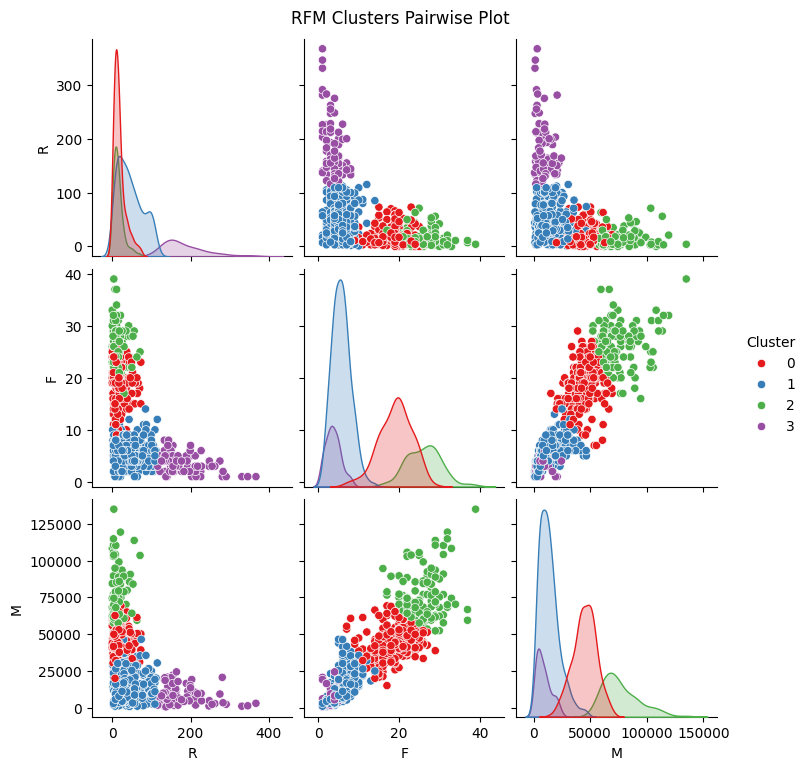

In [8]:
# 4. 繪製含有分群色彩的成對散布圖
sns.pairplot(result_df, vars=['R', 'F', 'M'], hue='Cluster', palette='Set1', diag_kind='kde')
plt.suptitle('RFM Clusters Pairwise Plot', y=1.02)
plt.show()